<a href="https://colab.research.google.com/github/March001xx/censimento-sesso-artisti/blob/main/Copia_di_Progetto_Arianna%2C_Viola%2C_Marcello.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

# Progetto Menin Arianna, Amadori Viola, Fiumana Marcello

## 1. Introduzione

Progetto realizzato da: Menin Arianna, Amadori Viola, Fiumana Marcello.
Analisi di un database storico artistico.

### 1.1. Obiettivi

1. Analisi d'insieme del database per capire innanzitutto di cosa si tratta.
2. Pulizia dati.
3. Dividere artsti uomini e artiste donne per analizzare le differenze tra i due dataframe con creazione di grafici.

### 1.2. Dati utilizzati

I dati in input sono costituiti da un file CSV di 229.3+ KB ("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv").

I dati in output consistono in questo Notebook Colab, contenente testo e codice per l'analisi computazionale dei dati.

| Colonna          | Tipo di Dato | Descrizione                                                                  | Esempio                               |
| :--------------- | :----------- | :--------------------------------------------------------------------------- | :------------------------------------ |
| `id`             | `object`     | Identificativo univoco dell'opera d'arte, spesso un URL Wikidata.            | `http://www.wikidata.org/entity/Q428274` |
| `titolo`         | `object`     | Titolo dell'opera d'arte.                                                    | `Nascita di Venere`                   |
| `artisti`        | `object`     | Nome dell'artista o degli artisti, con indicazione del genere (maschio/femmina) quando disponibile. | `Raffaello Sanzio (maschio)`          |
| `data_creazione` | `float64`    | Anno di creazione dell'opera, convertito in numerico (float).                | `1485.0`                              |
| `generi`         | `object`     | Generi artistici a cui appartiene l'opera (può contenere più generi separati da `; `). | `nudo artistico; pittura mitologica` |
| `luoghi`         | `object`     | Luoghi associati all'opera, come musei o collezioni.                         | `Galleria Palatina`                   |
| `collezioni`     | `object`     | Collezioni o istituzioni che detengono l'opera.                              | `Palazzo degli Uffizi`                |
| `contenuti`      | `object`     | Descrizione dei contenuti o soggetti rappresentati nell'opera.               | `Maria; donna; piante`                |
| `movimenti`      | `object`     | Movimento artistico a cui l'opera appartiene.                                | `rinascimento italiano`               |
| `soggetti`       | `object`     | Soggetti specifici raffigurati nell'opera.                                   | `Città ideale`                        |
| `altezza`        | `float64`    | Altezza dell'opera in unità non specificate (probabilmente cm), numerico.   | `175.0`                               |
| `larghezza`      | `float64`    | Larghezza dell'opera in unità non specificate (probabilmente cm), numerico.| `162.0`                               |




### 1.3. Organizzazione

I dati in output verranno lavorati su Google Colab.

### 1.5. Preservazione

Dove e come pianificate di preservare i dati

### 1.6. Accesso e Utilizzo

Licenza del progetto

## 2. Struttura


* Introduzione
* Caricamento e ispezione dei dati
* Processamento dei dati
* Analisi dei dati
  * Exploratory Data Analysis
  * Explanatory Data Analysis
* Conclusione

## 3. Codice utile

Qui vi lascio pezzi di codice completi o semi-completi da utilizzare, di cui vi ho parlato durante le lezioni.

Vi consiglio **caldamente** di dare un occhio anche alla documentazione ufficiale di Python e Pandas, e a chiedere spiegazioni a un'AI se avete dubbi o se trovate un ostacolo che non riuscite a superare.

* [Chatbot dedicato al corso](https://www.google.com/url?q=https%3A%2F%2Fgemini.google.com%2Fgem%2F1jP2JvydYTq9pm7JiZLFcCowTliR2gBaD%3Fusp%3Dsharing)
* [Documentazione Python](https://docs.python.org/3/)
* [Documentazione Pandas](https://pandas.pydata.org/docs/user_guide/index.html#user-guide)

Non partite subito col botto. Prendetevi tempo a esplorare i dati, capire se ci sono problemi, capire cosa vi interessa, e nel frattempo provate a maturare domande possibili a cui rispondere con l'analisi.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv")

Adesso andiamo ad analizzare questo dataset, per capire di cosa si tratta e per formulare poi le nostre domande ed i nostri obbiettivi.

Innanzitutto, **apriamolo**:

In [ ]:
df

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0


In [ ]:
df.shape

(2444, 12)

analizziamo solamente le **colonne** _per ora_ ma mettiamole anche **in lista** per leggerle meglio:

In [ ]:
df.columns

Index(['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi',
       'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza',
       'larghezza'],
      dtype='object')

In [ ]:
cols = df.columns.tolist()
print(cols)

['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi', 'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza', 'larghezza']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


Vediamo che in molte colonne mancano dei dati, ce ne occuperemo in seguito...
mentre notiamo subito invece che i dati per altezza e larghezza sono già come float che è quello che vogliamo, ottimo. Controlliamo che non ci siano ripetizioni...

In [ ]:
df.duplicated()
print(df.duplicated().value_counts())

False    2444
Name: count, dtype: int64


Ora ci rimane solo da cambiare la colonna "data_creazione" poichè le date sono presentate come stringhe e non come numeri (non siamo sicuri se in questo caso siccome è solo l'anno e non una data completa sia meglio renderla in float e non in date time):

In [ ]:
df.filter(['data_creazione'])

,data_creazione
0,1510
1,1485
2,1546
3,1483
4,1480
...,...
2439,1600
2440,1898
2441,1600
2442,1700


In [ ]:
df['data_creazione'] = pd.to_numeric(df['data_creazione'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1448 non-null   float64
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(3), object(9)
memory usage: 229.3+ KB


Andiamo a guardare i nomi degli artisti e ci sembra, anche grazie alla sottocategoria, che sono tutti maschi (nelle righe che ci fa vedere questa tabella), andiamo quindi a filtrare solo la colonna con i nomi degli artisti...

In [ ]:
df.filter(['artisti'])

,artisti
0,Raffaello Sanzio (maschio)
1,Sandro Botticelli (maschio)
2,Tiziano Vecellio (maschio)
3,Perugino (maschio)
4,Sandro Botticelli (maschio)
...,...
2439,Lambert Sustris (maschio)
2440,Giuseppe Riva (pittore 1861-1948) (maschio)
2441,NaN
2442,NaN


Ci chiediamo quindi quanti siano veramente gli artisti **maschi**:

In [ ]:
filtro_uomini = df['artisti'].str.contains('maschio', na=False)
df_uomini = df[filtro_uomini]
df_uomini

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510.0,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485.0,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546.0,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483.0,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480.0,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2437,http://www.wikidata.org/entity/Q137268771,Madonna orante,Giovanni Battista Salvi (maschio),1640.0,arte religiosa,deposito del museo,Collezione Lochis; Accademia Carrara,Maria; preghiera; aureola,NaN,Maria,47.0,37.0
2438,http://www.wikidata.org/entity/Q137040888,San Gerolamo penitente,Tiziano Vecellio (maschio),1600.0,arte religiosa,Accademia nazionale di San Luca,Accademia nazionale di San Luca,leone; libro; albero; crocifisso; cranio umano...,pittura veneta,San Girolamo nel deserto,107.5,76.5
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600.0,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898.0,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0


In [ ]:
print(f"Il numero di artisti uomini nel dataset è: {len(df_uomini)}")

Il numero di artisti uomini nel dataset è: 2124


Vogliamo analizzare a questo punto solo le artiste donne per cui andiamo a estrapolare dalla tabella totale solo le artiste donne analizzando la colonna "artisti" e inidicando la sottocategoria (femmina):

In [ ]:
df.loc[df["artisti"].str.contains("femmina", na=False)]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
6,http://www.wikidata.org/entity/Q532486,Giuditta con la sua ancella,Artemisia Gentileschi (femmina),1610.0,arte religiosa,Palazzo Pitti,Galleria Palatina,Giuditta e Oloferne; Giuditta,NaN,Giuditta e Oloferne,114.0,93.5
346,http://www.wikidata.org/entity/Q19390001,Autoritratto nello studio,Lavinia Fontana (femmina),1579.0,autoritratto,Corridoio Vasariano,Palazzo degli Uffizi; Corridoio Vasariano,Lavinia Fontana,NaN,Lavinia Fontana,NaN,NaN
350,http://www.wikidata.org/entity/Q19361572,Autoritratto di Elisabeth Luisa Vigée-Le Brun,Élisabeth Vigée Le Brun (femmina),1790.0,autoritratto,Palazzo degli Uffizi,Palazzo degli Uffizi,Élisabeth Vigée Le Brun,NaN,Élisabeth Vigée Le Brun,100.0,81.0
398,http://www.wikidata.org/entity/Q28113316,Donna con turbante,Ginevra Cantofoli (femmina),1650.0,ritratto,Galleria nazionale d'arte antica,Galleria nazionale d'arte antica,turbante; Beatrice Cenci; donna giovane,NaN,Beatrice Cenci,64.5,49.0
405,http://www.wikidata.org/entity/Q29997042,Ritratto di neonata nella culla,Lavinia Fontana (femmina),1583.0,ritratto,Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna,neonato,NaN,NaN,113.0,126.0
406,http://www.wikidata.org/entity/Q29654663,Ritratto di Paolo Morigia,Fede Galizia (femmina),1593.0,ritratto,Pinacoteca Ambrosiana,Pinacoteca Ambrosiana,Paolo Morigia,manierismo,Paolo Morigia,88.0,79.0
408,http://www.wikidata.org/entity/Q29015025,Betsabea,Artemisia Gentileschi (femmina),NaN,nudo artistico; arte di genere; arte religiosa,Italia,NaN,donna; nudità; albero; mammella; palazzo; perl...,NaN,Betsabea al bagno,288.0,228.0
424,http://www.wikidata.org/entity/Q30605361,Susanna e i vecchioni,Onofrio Palumbo (maschio); Artemisia Gentilesc...,1652.0,arte religiosa,Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna,Susanna e i vecchioni,NaN,Susanna e i vecchioni,NaN,NaN
436,http://www.wikidata.org/entity/Q45361473,Compianto sul Cristo morto,Plautilla Nelli (femmina),1560.0,arte religiosa,Museo di San Marco,Museo di San Marco,Gesù,manierismo,Compianto sul Cristo morto,288.0,192.0
472,http://www.wikidata.org/entity/Q52155641,Autoritratto con ombrello verde,Elisabeth Chaplin (femmina),1907.0,autoritratto,Galleria d'arte moderna di Firenze,Galleria d'arte moderna di Firenze,Elisabeth Chaplin,NaN,Elisabeth Chaplin,89.0,60.0


A questo punto creiamo un nuovo dataframe composto solo dalle artiste donne e contiamo da quante righe è costituito quindi da quante artiste:

In [ ]:
df_donne = df[df["artisti"].str.contains("femmina", na=False)]

print(f"Il numero di artiste donne nel dataset è: {len(df_donne)}")

Il numero di artiste donne nel dataset è: 36


contiamo quindi i due numeri ottenuti:

In [ ]:
print(2124+36)

2160


Per completezza e per vedere se tutti gli artisti sono stati contati correttamente cerchiamo ora gli artisti senza nome e quindi genere, non andiamo a eliminare completamente le righe con artisti senza nome perchè andrebbe ad eliminare troppi dati possibilmente utili:

In [ ]:
df.isnull().sum()

,0
id,0
titolo,0
artisti,285
data_creazione,996
generi,920
luoghi,82
collezioni,208
contenuti,423
movimenti,2062
soggetti,778


In [ ]:
filtro_nan = df['artisti'].isna()
df_ignoti = df[filtro_nan]
df_ignoti.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
23,http://www.wikidata.org/entity/Q1113938,Città ideale - Urbino,NaN,1480.0,paesaggio urbano,Galleria nazionale delle Marche; Ex monastero ...,Galleria nazionale delle Marche,città ideale,rinascimento italiano,Città ideale,67.7,239.4
36,http://www.wikidata.org/entity/Q1119008,Pala di Asolo,NaN,1506.0,arte religiosa,duomo di Asolo,duomo di Asolo,Maria; donna; piante; uomo; nuvola; Assunzione...,Alto Rinascimento,Assunzione di Maria,175.0,162.0
217,http://www.wikidata.org/entity/Q3889229,Pala dell'Alabarda,NaN,1530.0,arte religiosa,Palazzo Bosdari,Pinacoteca civica Francesco Podesti,Maria; Simone il Cananeo; San Lorenzo; angelo;...,pittura veneta,Sacra conversazione,295.0,210.0
220,http://www.wikidata.org/entity/Q3889255,Pala di San Francesco al Monte,NaN,1526.0,arte religiosa,Palazzo Pianetti,Palazzo Pianetti,Maria; donna; ragazzo; madre; Sofronio Eusebio...,NaN,Sacra conversazione,240.0,160.0
223,http://www.wikidata.org/entity/Q3907344,Polimnia,NaN,NaN,pittura mitologica,Gemäldegalerie,Gemäldegalerie,Polimnia,NaN,NaN,116.6,70.5


In [ ]:
print(len(df_ignoti))

285


In [ ]:
print(2160+285)

2445


Realizziamo ora un grafico a torta con i dati acquisiti per vedere le differenze tra i sessi all'interno di questo databaase:

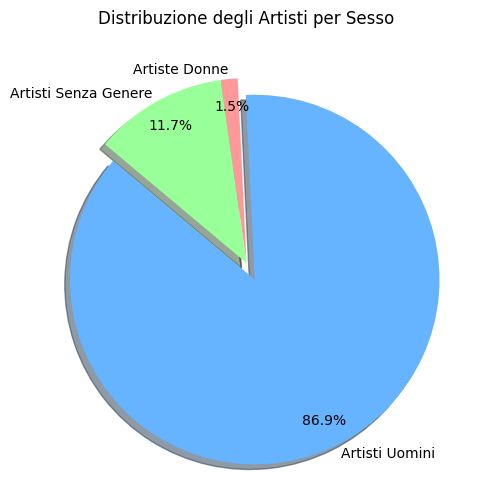

In [ ]:
import matplotlib.pyplot as plt

labels = ['Artisti Uomini', 'Artiste Donne', 'Artisti Senza Genere']
sizes = [len(df_uomini), len(df_donne), len(df_ignoti)]
explode = (0.1, 0, 0)

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, pctdistance=0.85, labeldistance=1.05)
plt.title('Distribuzione degli Artisti per Sesso')
plt.show()

Ritorniamo al df dei soli uomini, analizzando ora i generi per sapere quali sono i più realizzati:

In [ ]:
df_uomini.filter(['generi'])

,generi
0,ritratto
1,nudo artistico; pittura mitologica
2,ritratto; ritratto di gruppo
3,arte religiosa
4,allegoria; pittura mitologica
...,...
2437,arte religiosa
2438,arte religiosa
2439,nudo artistico; pittura mitologica
2440,ritratto


Andiamo a dividere i generi che sono uniti:

In [ ]:
df_uomini['generi'].str.split('; ').explode()

,generi
0,ritratto
1,nudo artistico
1,pittura mitologica
2,ritratto
2,ritratto di gruppo
...,...
2438,arte religiosa
2439,nudo artistico
2439,pittura mitologica
2440,ritratto


In [ ]:
conteggio_generi_uomini = df_uomini['generi'].str.split('; ').explode().value_counts()
percentuale_generi_uomini = df_uomini['generi'].str.split('; ').explode().value_counts(normalize=True) * 100

riepilogo_generi_uomini = pd.DataFrame({
    'Conteggio': conteggio_generi_uomini,
    'Percentuale %': percentuale_generi_uomini.round(2)
})

print("--- Analisi dei Generi Artistici: Artisti Uomini ---")
print(riepilogo_generi_uomini.head(10))

--- Analisi dei Generi Artistici: Artisti Uomini ---
                       Conteggio  Percentuale %
generi                                         
arte religiosa               754          53.97
ritratto                     355          25.41
pittura mitologica            69           4.94
arte di genere                49           3.51
autoritratto                  36           2.58
nudo artistico                21           1.50
pittura storica               20           1.43
allegoria                     18           1.29
pittura paesaggistica         17           1.22
paesaggio urbano              14           1.00


<Axes: title={'center': 'Generi più realizzati dagli artisti uomini'}, ylabel='generi'>

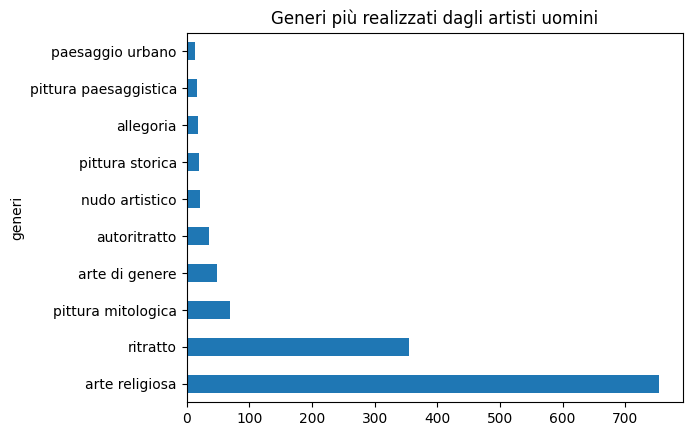

In [ ]:
df_uomini['generi'].str.split('; ').explode().value_counts().head(10).plot.barh(title="Generi più realizzati dagli artisti uomini")

Ci poniamo ora la stessa domanda ma per quanto riguarda le artiste donne, anche qui andando prima a dividere i generi uniti nella stessa stringa:

In [ ]:
df_donne.filter(['generi'])

,generi
6,arte religiosa
346,autoritratto
350,autoritratto
398,ritratto
405,ritratto
406,ritratto
408,nudo artistico; arte di genere; arte religiosa
424,arte religiosa
436,arte religiosa
472,autoritratto


In [ ]:
df_donne['generi'].str.split('; ').explode()

,generi
6,arte religiosa
346,autoritratto
350,autoritratto
398,ritratto
405,ritratto
406,ritratto
408,nudo artistico
408,arte di genere
408,arte religiosa
424,arte religiosa


In [ ]:
conteggio_generi_donne = df_donne['generi'].str.split('; ').explode().value_counts()
percentuale_generi_donne = df_donne['generi'].str.split('; ').explode().value_counts(normalize=True) * 100

riepilogo_donne = pd.DataFrame({
    'Conteggio': conteggio_generi_donne,
    'Percentuale %': percentuale_generi_donne.round(2)
})

print("--- Analisi dei Generi Artistici: Artiste Donne ---")
print(riepilogo_donne)

--- Analisi dei Generi Artistici: Artiste Donne ---
                       Conteggio  Percentuale %
generi                                         
ritratto                      15          48.39
arte religiosa                 7          22.58
autoritratto                   5          16.13
arte di genere                 2           6.45
nudo artistico                 1           3.23
pittura paesaggistica          1           3.23


<Axes: title={'center': 'Generi più realizzati dalle artiste donne'}, ylabel='generi'>

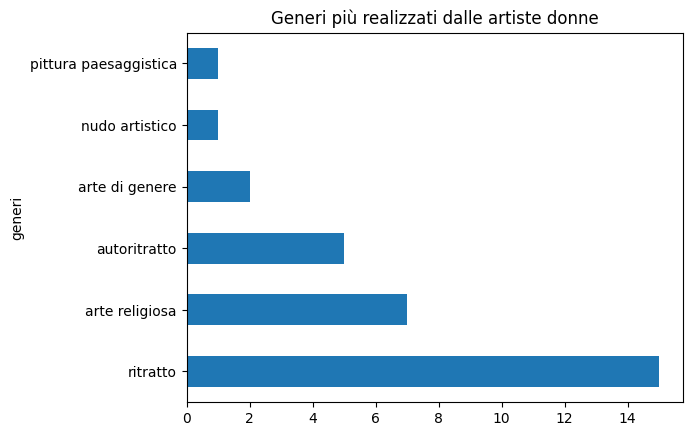

In [ ]:
df_donne['generi'].str.split('; ').explode().value_counts().plot.barh(title="Generi più realizzati dalle artiste donne")

## 4. Conclusione

Abbiamo quindi analizzato questo dataset storico artistico focalizzandoci sull'analisi dei sessi per quanto riguarda gli artisti descritti e abbiamo notato come il numero di artisti maschi rispetto alle artiste femmine sia di gran lunga superiore, tanto che anche gli artisti non identificati poichè senza nome superano il numero di artiste donne rappresentate.

Dopodichè abbiamo analizzato il genere "preferito" dagli artisti maschi e dalle artiste femmine notando come per i primi il prevalente sia l'arte religiosa seguita dal ritratto mentre per le donne i generi si scambino di posizione.

Grazie per l'attenzione:

Arianna Menin, Viola Amadori, Marcello Fiumana.